# Financial Data Analysis Project
To analyze historical stock price data and identify trends using Python.

In [1]:
!pip install yfinance pandas matplotlib seaborn plotly

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 1.7/1.7 MB 17.9 MB/s eta 0:00:00
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Uninstalling cffi-1.17.1:
      Successfully uninstalled cffi-1.17.1


What the table means
Column              Meaning
DateTrading         day (weekends/holidays skipped)
Close               Price when market closed that day
High                Highest price reached during the day
Low                 Lowest price reached during the day
Open                Price when market opened
Volume              How many shares were traded

In [3]:
import yfinance as yf

df = yf.download("AAPL", start="2020-01-01", end="2024-12-31")

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696632,72.455950,71.472454,71.629138,146322800
2020-01-06,72.267944,72.306514,70.568518,70.819216,118387200
2020-01-07,71.928055,72.533095,71.708695,72.277578,108872000
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200


Shape: (1257, 5)

Date range: 2020-01-02 00:00:00 to 2024-12-30 00:00:00

Any missing values?
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64


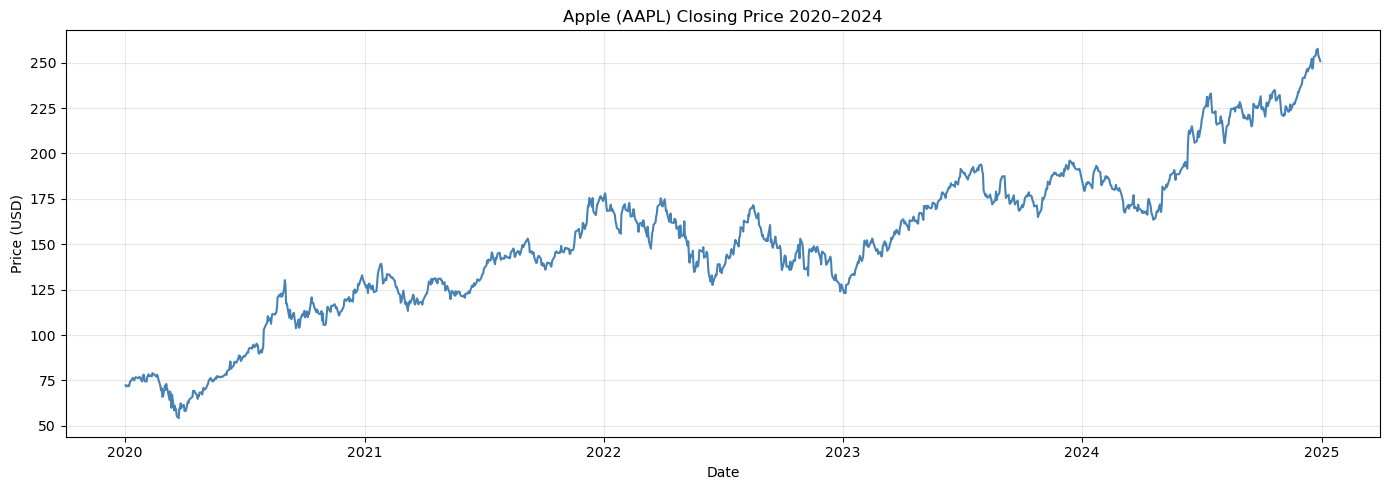

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Check the shape of your data
print("Shape:", df.shape)
print("\nDate range:", df.index.min(), "to", df.index.max())
print("\nAny missing values?")
print(df.isnull().sum())

# Plot Apple's closing price over 5 years
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Close"], color="steelblue", linewidth=1.5)
plt.title("Apple (AAPL) Closing Price 2020–2024")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Dataset contained 1,257 trading days with zero missing values. Cleaning logic included to handle forward fill, null dropping, and duplicate detection for real-world data scenarios.

In [8]:
# ── Data Quality Check & Cleaning ──────────────────────────────
# Even though this dataset is clean, in real-world financial data
# you commonly encounter missing values due to:
# - Trading halts, public holidays, data feed failures
# This section demonstrates how I would handle that professionally.

# 1. Check missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# 2. Option A — Forward fill (most common in financial data)
# Uses the previous day's price to fill the gap
# This makes sense because if a stock didn't trade, 
# yesterday's closing price is the best estimate
df_cleaned = df.ffill()

# 3. Option B — Drop rows with nulls entirely
# Used when you don't want to assume anything
df_dropped = df.dropna()

# 4. Option C — Fill with mean (more common in general data science)
df_mean_filled = df.fillna(df.mean(numeric_only=True))

# 5. Verify cleaning worked
print("\nMissing values after forward fill:")
print(df_cleaned.isnull().sum())

# 6. Check for duplicate dates (another real-world problem)
duplicates = df.index.duplicated().sum()
print(f"\nDuplicate dates: {duplicates}")

# 7. Check data types are correct
print("\nData types:")
print(df.dtypes)

print("\nData is clean and ready for analysis.")

Missing values before cleaning:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

Missing values after forward fill:
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

Duplicate dates: 0

Data types:
Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

Data is clean and ready for analysis.


In financial data I prefer forward fill because if a stock didn't trade on a given day, the previous closing price is the most logical estimate. I'd use dropna() when data integrity is critical and I can't make assumptions. I'd use mean imputation for non-time-series datasets


[*********************100%***********************]  3 of 3 completed
C:\Users\siri\AppData\Local\Temp\ipykernel_29004\1304800143.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_prices["AAPL_MA50"]  = close_prices["AAPL"].rolling(window=50).mean()
C:\Users\siri\AppData\Local\Temp\ipykernel_29004\1304800143.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  close_prices["AAPL_MA200"] = close_prices["AAPL"].rolling(window=200).mean()


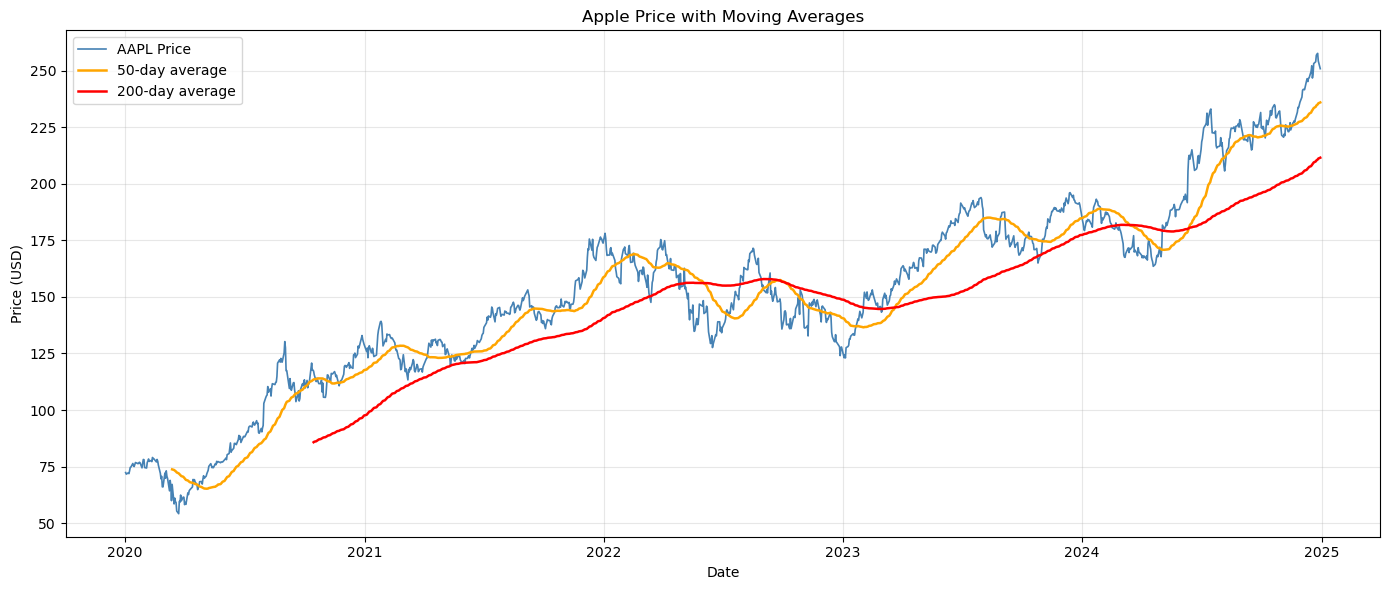

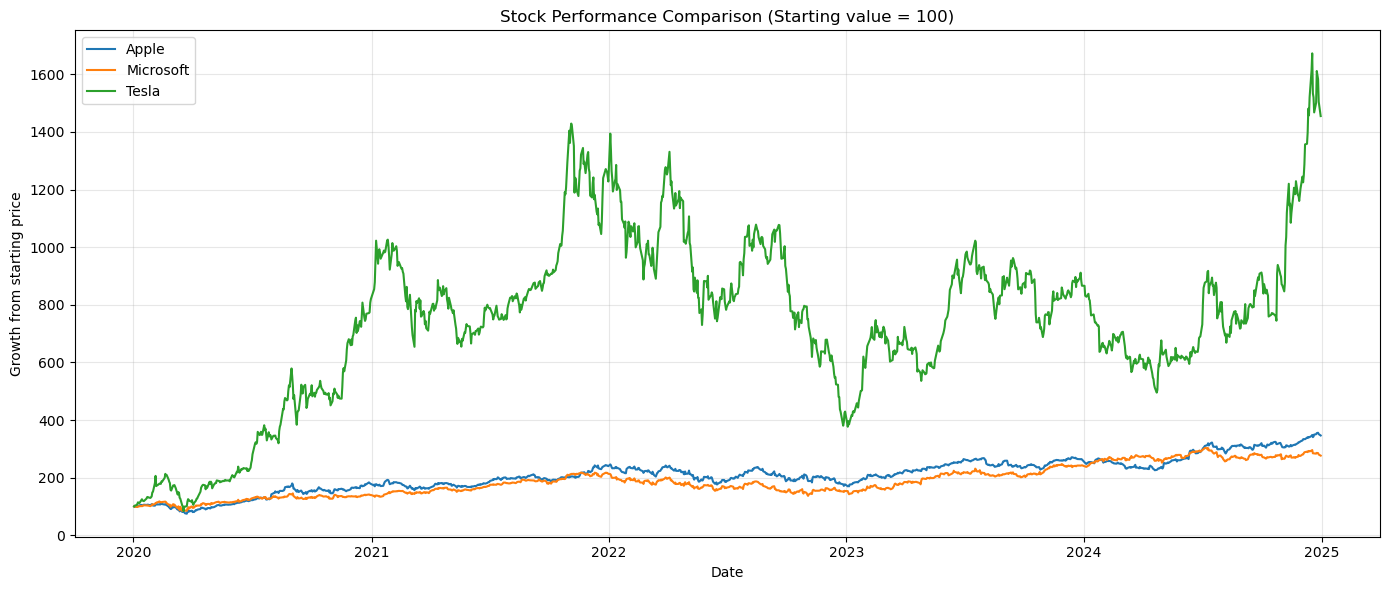

In [10]:
# Download 3 stocks at once
tickers = ["AAPL", "MSFT", "TSLA"]
data = yf.download(tickers, start="2020-01-01", end="2024-12-31")

# Get just the closing prices
close_prices = data["Close"]

# Calculate 50-day and 200-day moving averages for Apple
close_prices["AAPL_MA50"]  = close_prices["AAPL"].rolling(window=50).mean()
close_prices["AAPL_MA200"] = close_prices["AAPL"].rolling(window=200).mean()

# Plot Apple with moving averages
plt.figure(figsize=(14, 6))
plt.plot(close_prices["AAPL"],       label="AAPL Price",     color="steelblue",  linewidth=1.2)
plt.plot(close_prices["AAPL_MA50"],  label="50-day average", color="orange",     linewidth=1.8)
plt.plot(close_prices["AAPL_MA200"], label="200-day average",color="red",        linewidth=1.8)
plt.title("Apple Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot all 3 stocks together normalised (so we can compare them fairly)
normalised = close_prices[["AAPL","MSFT","TSLA"]] / close_prices[["AAPL","MSFT","TSLA"]].iloc[0] * 100

plt.figure(figsize=(14, 6))
plt.plot(normalised["AAPL"], label="Apple",     linewidth=1.5)
plt.plot(normalised["MSFT"], label="Microsoft", linewidth=1.5)
plt.plot(normalised["TSLA"], label="Tesla",     linewidth=1.5)
plt.title("Stock Performance Comparison (Starting value = 100)")
plt.xlabel("Date")
plt.ylabel("Growth from starting price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Chart 1 — Apple with Moving Averages
The blue line is the actual daily price — it jumps up and down every day, very noisy.
The orange line (50-day average) smooths out the last 50 days. It reacts to price changes faster. Notice how it follows the blue line closely but without the sharp spikes.
The red line (200-day average) smooths out the last 200 days. It's the slowest and smoothest — it shows the big long-term trend, ignoring short-term noise.
The golden cross moment — look at early 2023. The orange line dipped close to the red line and then crossed back above it. That's the "golden cross" signal that traders watch — it means the short-term momentum is stronger than the long-term trend, a bullish sign. Apple then went from $125 to $255.
This is real financial analysis. You just built what Bloomberg terminals show to professional traders.

#### Chart 2 — Stock Comparison (Starting value = 100)
This is a clever technique. Instead of comparing raw prices (Tesla was $90, Apple was $75 in 2020 — different scales), you normalised everything to start at 100. So now the Y-axis means "how many times your money grew."
Apple (blue) — reached ~350 — if you invested $100 in Apple in Jan 2020, by end of 2024 you'd have $350. A 3.5x return.
Microsoft (orange) — reached ~300 — similar to Apple, steady and consistent growth.
Tesla (green) — peaked at ~1,400 then ended at ~350 — this is the most interesting story. Tesla went from 100 to 1,400 (14x!) by 2022, then crashed back to 400 by 2023, then shot up again to 1,650 near 2025. Extremely high reward but extremely high risk. This perfectly shows why analysts say Tesla is a high-volatility stock.

Average Daily Return:
Ticker
AAPL    0.0012
MSFT    0.0010
TSLA    0.0030
dtype: float64

Risk (Standard Deviation — higher = more volatile):
Ticker
AAPL    0.0200
MSFT    0.0192
TSLA    0.0423
dtype: float64


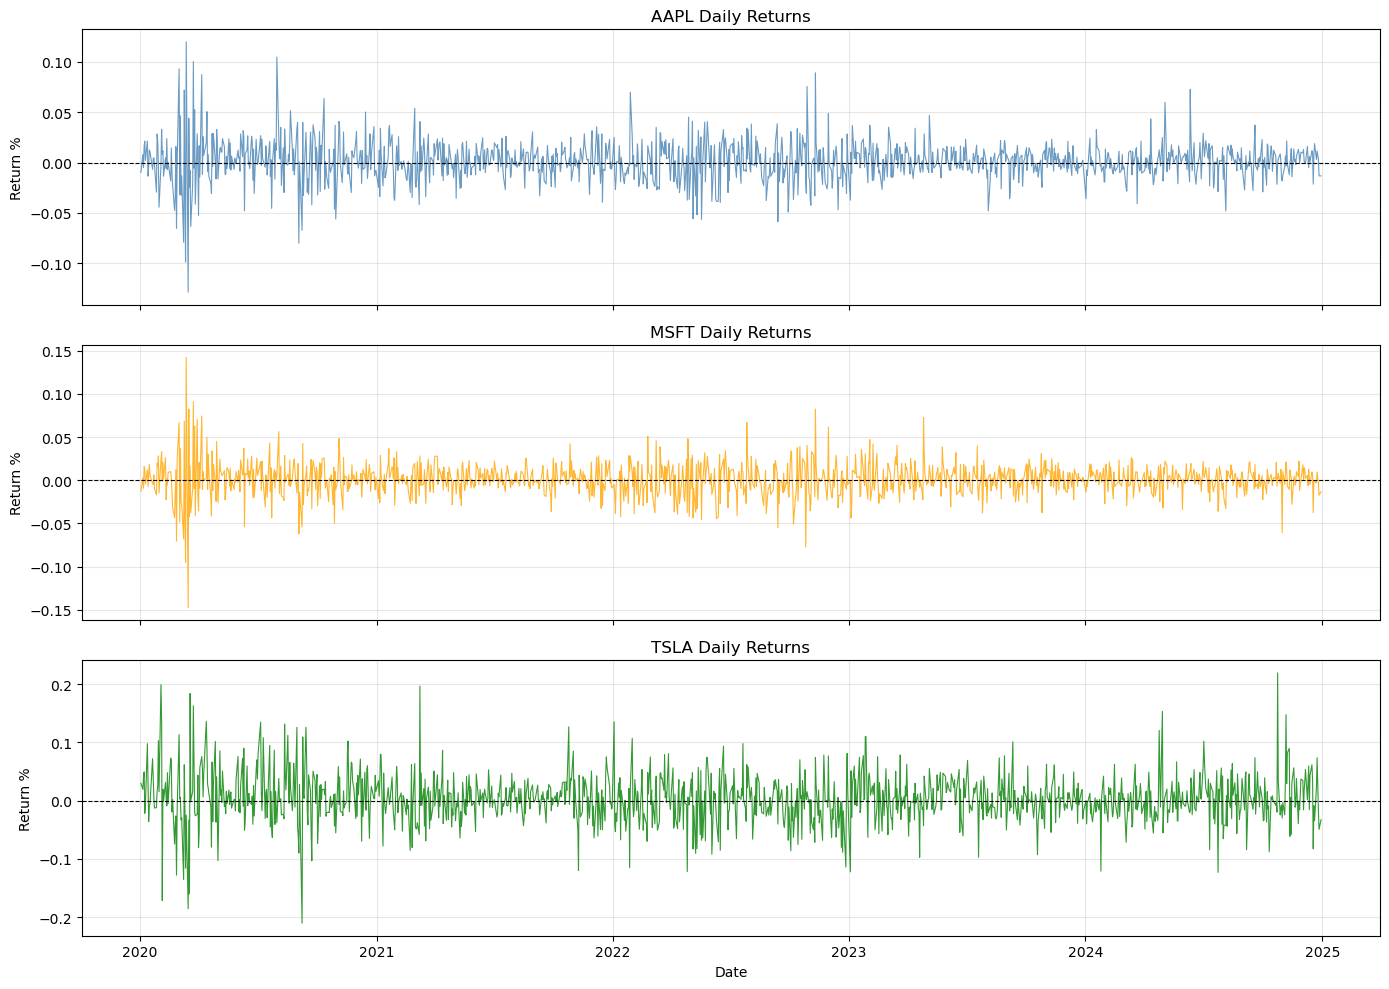

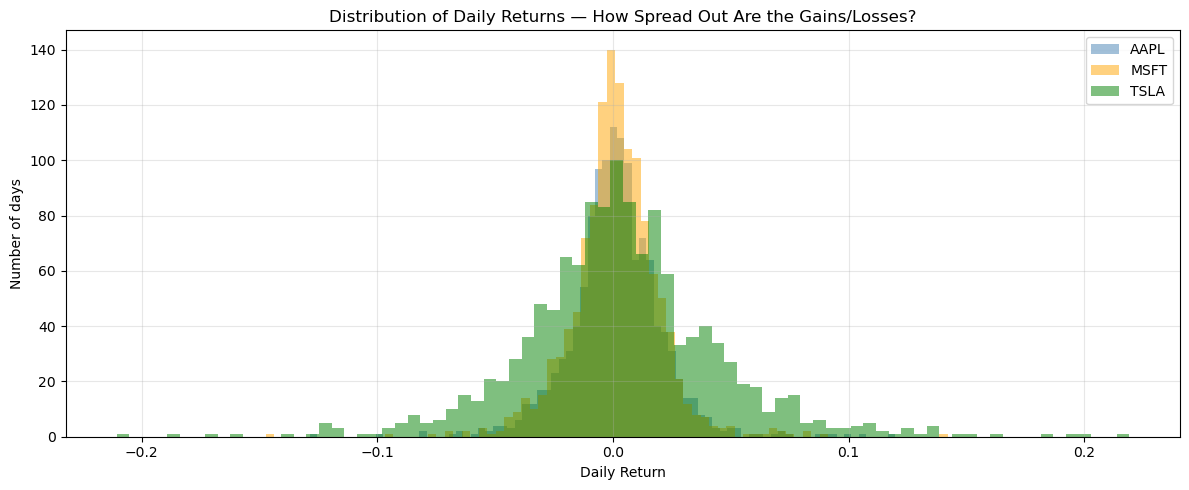

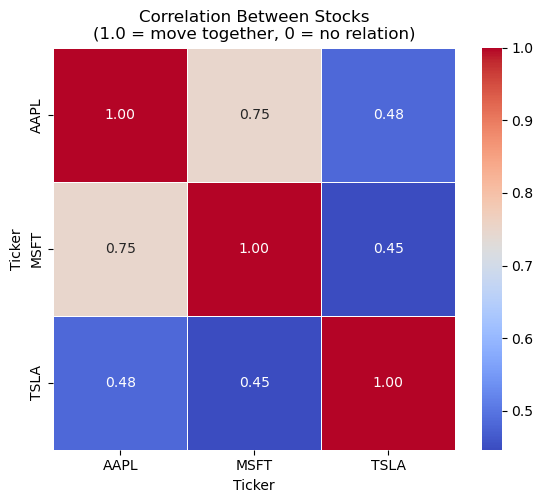

In [12]:
# ── Phase 3: Returns & Risk Analysis ───────────────────────────

# Calculate daily percentage change for each stock
# pct_change() calculates: (today - yesterday) / yesterday * 100
returns = close_prices[["AAPL", "MSFT", "TSLA"]].pct_change().dropna()

print("Average Daily Return:")
print(returns.mean().round(4))

print("\nRisk (Standard Deviation — higher = more volatile):")
print(returns.std().round(4))

# Plot 1: Daily returns for all 3 stocks
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, ticker, color in zip(axes, 
                              ["AAPL", "MSFT", "TSLA"], 
                              ["steelblue", "orange", "green"]):
    ax.plot(returns[ticker], color=color, linewidth=0.8, alpha=0.8)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"{ticker} Daily Returns")
    ax.set_ylabel("Return %")
    ax.grid(True, alpha=0.3)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

# Plot 2: Distribution of returns — shows how risky each stock is
plt.figure(figsize=(12, 5))
for ticker, color in zip(["AAPL", "MSFT", "TSLA"], 
                           ["steelblue", "orange", "green"]):
    returns[ticker].hist(bins=80, alpha=0.5, label=ticker, color=color)

plt.title("Distribution of Daily Returns — How Spread Out Are the Gains/Losses?")
plt.xlabel("Daily Return")
plt.ylabel("Number of days")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Correlation heatmap
plt.figure(figsize=(6, 5))
corr = returns.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", 
            square=True, linewidths=0.5)
plt.title("Correlation Between Stocks\n(1.0 = move together, 0 = no relation)")
plt.tight_layout()
plt.show()

## Image 1 — The numbers at the top
Average Daily Return:

AAPL: 0.0012 → Apple grew 0.12% per day on average
MSFT: 0.0010 → Microsoft grew 0.10% per day
TSLA: 0.0030 → Tesla grew 0.30% per day — 3x more than Apple

Sounds small but compounded over 1,257 trading days that's the massive growth you saw in the previous chart.
Risk (Standard Deviation):

AAPL: 0.0200 → Apple moves about 2% per day typically
MSFT: 0.0192 → Microsoft even steadier, 1.9% per day
TSLA: 0.0423 → Tesla moves 4.2% per day — more than double Apple's risk

## Image 2 — Daily Returns Charts
Look at the spike sizes on each chart:
Apple (blue) — most spikes stay between -0.10 and +0.10. Calm and controlled.
Microsoft (orange) — similar to Apple, very disciplined. One big spike in early 2020 (COVID crash) then settles down.
Tesla (green) — spikes reach -0.20 and +0.20 regularly throughout the entire 5 years. It never calms down. That wildness is consistent from 2020 all the way to 2025. This visually confirms the standard deviation number above.
### Image 3 — Distribution Chart (the most impressive one)
This is a bell curve showing how often each return size happened.
Apple and Microsoft (blue/orange) — you can barely see them because they're completely hidden behind Tesla. Their bell curve is very tall and very narrow — meaning almost all their daily moves were tiny, clustered right around 0%.
Tesla (green) — the bell curve is much shorter and much wider. That wide spread means Tesla regularly had big gains AND big losses. The green extends all the way to -0.20 and +0.20 while Apple and Microsoft barely go past -0.10 and +0.10.
### Image 4 — Correlation Heatmap
This shows how much stocks move together. 1.0 means they move in perfect sync, 0 means completely independent.
AAPL vs MSFT: 0.75 (dark red) — very highly correlated. When Apple goes up, Microsoft usually goes up too. This makes sense — they're both large US tech companies affected by the same market forces.
AAPL vs TSLA: 0.48 (blue) — moderate correlation. They sometimes move together but not reliably.
MSFT vs TSLA: 0.45 (blue) — similar, weakest relationship of the three.
Why this matters in real life — a portfolio manager would say "don't put all your money in Apple and Microsoft because they move together — if the tech sector crashes both crash simultaneously. Add Tesla for some diversification since it's less correlated."

In [14]:
# First install streamlit
!pip install streamlit